In [1]:
import pandas as pd
from rouge_score import rouge_scorer
from bert_score import score as bertscore
import numpy as np
from scipy import stats


ft = pd.read_csv("finetuned_clean_judged.csv", sep=",", engine="python", on_bad_lines='warn')
zs = pd.read_csv("zeroshot_clean_judged.csv", sep=",", engine="python", on_bad_lines='warn')

print(ft.shape)
print(ft.columns.tolist())
print(ft.head(2))

ft["model"] = "finetuned"
zs["model"] = "zeroshot"

# Shape check
print(ft.shape, zs.shape)

# Column check
expected_cols = ['example_id','issue','topic','stance','input_article',
                 'generated_summary','roundup_text','neutrality','coverage',
                 'faithfulness','roundup_alignment','reasoning']
print("Missing cols ft:", set(expected_cols) - set(ft.columns))
print("Missing cols zs:", set(expected_cols) - set(zs.columns))

# Null check on critical columns
for col in ['generated_summary', 'roundup_text', 'neutrality']:
    print(f"{col} nulls — ft: {ft[col].isnull().sum()}, zs: {zs[col].isnull().sum()}")

# Stance distribution
print(ft['stance'].value_counts())
print(zs['stance'].value_counts())


df = pd.concat([ft, zs], ignore_index=True)

# --- ROUGE ---
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_rouge(row):
    scores = scorer.score(row["roundup_text"], row["generated_summary"])
    return pd.Series({
        "rouge1_f": scores["rouge1"].fmeasure,
        "rouge2_f": scores["rouge2"].fmeasure,
        "rougeL_f": scores["rougeL"].fmeasure,
    })

rouge_df = df.apply(compute_rouge, axis=1)
df = pd.concat([df, rouge_df], axis=1)

# --- BERTScore (batched, slow — do once, cache) ---
P, R, F1 = bertscore(
    df["generated_summary"].tolist(),
    df["roundup_text"].tolist(),
    lang="en",
    rescale_with_baseline=True,
    verbose=True
)
df["bertscore_f1"] = F1.numpy()

df.to_csv("full_evaluated.csv", index=False, sep="\t")
print(df.groupby(["model", "stance"])[["rouge1_f","rouge2_f","rougeL_f","bertscore_f1"]].mean().round(4))

c:\Users\ImanGhotbi\.conda\envs\thes_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(921, 12)
['example_id', 'issue', 'topic', 'stance', 'input_article', 'generated_summary', 'roundup_text', 'neutrality', 'coverage', 'faithfulness', 'roundup_alignment', 'reasoning']
   example_id                                     issue           topic  \
0           0  'Howdy Modi' Event Draws President Trump  Foreign Policy   
1           0  'Howdy Modi' Event Draws President Trump  Foreign Policy   

   stance                                      input_article  \
0    left  HOUSTON — The foreign strategy of soothing ten...   
1  center  U.S. President Donald Trump and Indian Prime M...   

                                   generated_summary  \
0  Indian Prime Minister Narendra Modi met with P...   
1  President Donald Trump and Indian Prime Minist...   

                                        roundup_text  neutrality  coverage  \
0  President Donald Trump made an appearance at a...           4         3   
1  President Donald Trump made an appearance at a...           4         

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4596.84it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


calculating scores...
computing bert embedding.


100%|██████████| 34/34 [09:57<00:00, 17.57s/it]


computing greedy matching.


100%|██████████| 29/29 [00:00<00:00, 30.65it/s]
c:\Users\ImanGhotbi\.conda\envs\thes_env\Lib\site-packages\bert_score\score.py:149: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  baselines = torch.from_numpy(


done in 598.28 seconds, 3.08 sentences/sec
                  rouge1_f  rouge2_f  rougeL_f  bertscore_f1
model     stance                                            
finetuned center    0.3103    0.1192    0.2044        0.2384
          left      0.2936    0.1019    0.1920        0.1994
          right     0.3062    0.1085    0.1981        0.2170
zeroshot  center    0.3681    0.1357    0.2397        0.3266
          left      0.3419    0.1098    0.2177        0.2848
          right     0.3536    0.1199    0.2260        0.2988


In [2]:
import re
from sentibank import archive
load = archive.load()
analyzer = load.origin("NoVAD_v2013")  # check exact name — see note below

# Load warriner exactly as in EDA
load = archive.load()
warriner_raw = load.origin("NoVAD_v2013")
warriner = warriner_raw.set_index("Word")[["V.Mean.Sum", "A.Mean.Sum", "D.Mean.Sum"]]
warriner.columns = ["valence", "arousal", "dominance"]

WARRINER_NEUTRAL = 5.0

def compute_vad_warriner(text: str) -> dict:
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {"valence": WARRINER_NEUTRAL, "arousal": WARRINER_NEUTRAL,
                "dominance": WARRINER_NEUTRAL, "n_matched": 0, "n_tokens": 0, "coverage": 0.0}
    
    tokens = re.findall(r"[a-z]+", text.lower())
    v_scores, a_scores, d_scores = [], [], []
    
    for word in tokens:
        if word in warriner.index:
            v_scores.append(warriner.loc[word, "valence"])
            a_scores.append(warriner.loc[word, "arousal"])
            d_scores.append(warriner.loc[word, "dominance"])
    
    n_matched = len(v_scores)
    n_tokens  = len(tokens)
    
    return {
        "valence":   sum(v_scores) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "arousal":   sum(a_scores) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "dominance": sum(d_scores) / n_matched if n_matched > 0 else WARRINER_NEUTRAL,
        "n_matched": n_matched,
        "n_tokens":  n_tokens,
        "coverage":  n_matched / n_tokens if n_tokens > 0 else 0.0
    }

# Apply to generated_summary column
vad_results = df["generated_summary"].apply(compute_vad_warriner)
df["valence"]    = vad_results.apply(lambda x: x["valence"])
df["arousal"]    = vad_results.apply(lambda x: x["arousal"])
df["dominance"]  = vad_results.apply(lambda x: x["dominance"])
df["vad_coverage"] = vad_results.apply(lambda x: x["coverage"])
df["vad_n_matched"] = vad_results.apply(lambda x: x["n_matched"])

# Sanity check
print(df.groupby(["model", "stance"])[["valence","arousal","dominance","vad_coverage"]].mean().round(4))
print(f"\nRows with zero VAD coverage: {(df['vad_coverage'] == 0).sum()}")

                  valence  arousal  dominance  vad_coverage
model     stance                                           
finetuned center   5.2882   4.0588     5.4058        0.3055
          left     5.2831   4.0581     5.4103        0.3082
          right    5.3044   4.0663     5.4258        0.3097
zeroshot  center   5.2805   4.1115     5.4074        0.3257
          left     5.2835   4.1047     5.3982        0.3216
          right    5.3280   4.0961     5.4210        0.3247

Rows with zero VAD coverage: 0


In [3]:
from scipy import stats

# VAD spread: per story per model, how much does valence vary across L/C/R?
vad_spread = (
    df.groupby(["model", "example_id"])["valence"]
    .agg(lambda x: x.max() - x.min())
    .reset_index()
    .rename(columns={"valence": "valence_spread"})
)

print(vad_spread.groupby("model")["valence_spread"].describe().round(4))

# Significance test
ft_spread = vad_spread[vad_spread["model"] == "finetuned"]["valence_spread"]
zs_spread = vad_spread[vad_spread["model"] == "zeroshot"]["valence_spread"]

t, p = stats.ttest_ind(ft_spread, zs_spread)
cohen_d = (ft_spread.mean() - zs_spread.mean()) / np.sqrt(
    (ft_spread.std()**2 + zs_spread.std()**2) / 2
)
print(f"\nVAD spread — finetuned mean: {ft_spread.mean():.4f}, zeroshot mean: {zs_spread.mean():.4f}")
print(f"t={t:.3f}, p={p:.4f}, Cohen's d={cohen_d:.4f}")

           count    mean     std     min     25%     50%     75%     max
model                                                                   
finetuned  307.0  0.3794  0.2686  0.0167  0.2003  0.3244  0.4833  1.9048
zeroshot   307.0  0.3924  0.2241  0.0147  0.2282  0.3553  0.5393  1.1786

VAD spread — finetuned mean: 0.3794, zeroshot mean: 0.3924
t=-0.654, p=0.5135, Cohen's d=-0.0528


In [4]:
judge_cols = ["neutrality", "faithfulness", "roundup_alignment"]

# Judge scores by model and stance
print(df.groupby(["model", "stance"])[judge_cols].mean().round(4))

# Overall by model (collapsed across stances)
print(df.groupby("model")[judge_cols].mean().round(4))

# Statistical test: paired by example_id
from scipy import stats

for col in judge_cols:
    ft_scores = df[df["model"]=="finetuned"].sort_values(["example_id","stance"])[col].astype(float)
    zs_scores = df[df["model"]=="zeroshot"].sort_values(["example_id","stance"])[col].astype(float)
    t, p = stats.ttest_rel(ft_scores, zs_scores)
    d = (ft_scores.mean() - zs_scores.mean()) / ft_scores.std()
    print(f"{col}: t={t:.3f}, p={p:.4f}, Cohen's d={d:.4f}, ft_mean={ft_scores.mean():.3f}, zs_mean={zs_scores.mean():.3f}")

                  neutrality  faithfulness  roundup_alignment
model     stance                                             
finetuned center      4.0554        2.6938             2.5081
          left        3.9283        2.5375             2.2801
          right       4.0423        2.5603             2.3876
zeroshot  center      3.4300        4.2020             3.2508
          left        3.3616        4.1075             3.0651
          right       3.3160        4.1238             3.0879
           neutrality  faithfulness  roundup_alignment
model                                                 
finetuned      4.0087        2.5972             2.3920
zeroshot       3.3692        4.1444             3.1346
neutrality: t=20.212, p=0.0000, Cohen's d=0.7528, ft_mean=4.009, zs_mean=3.369
faithfulness: t=-46.106, p=0.0000, Cohen's d=-1.6765, ft_mean=2.597, zs_mean=4.144
roundup_alignment: t=-26.814, p=0.0000, Cohen's d=-0.8732, ft_mean=2.392, zs_mean=3.135


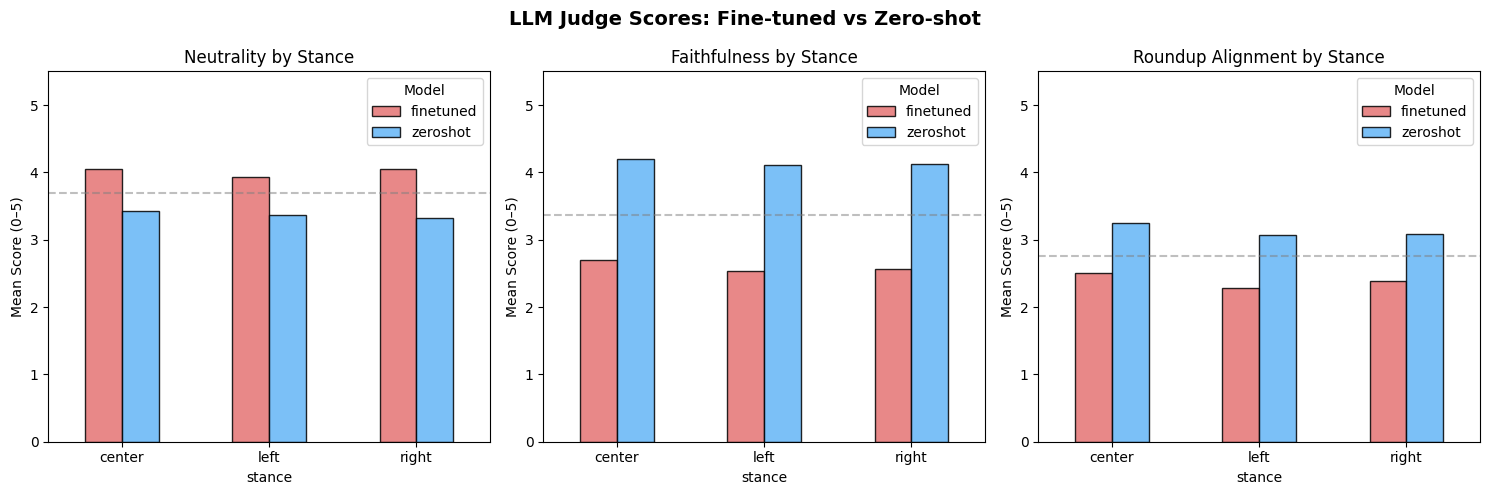

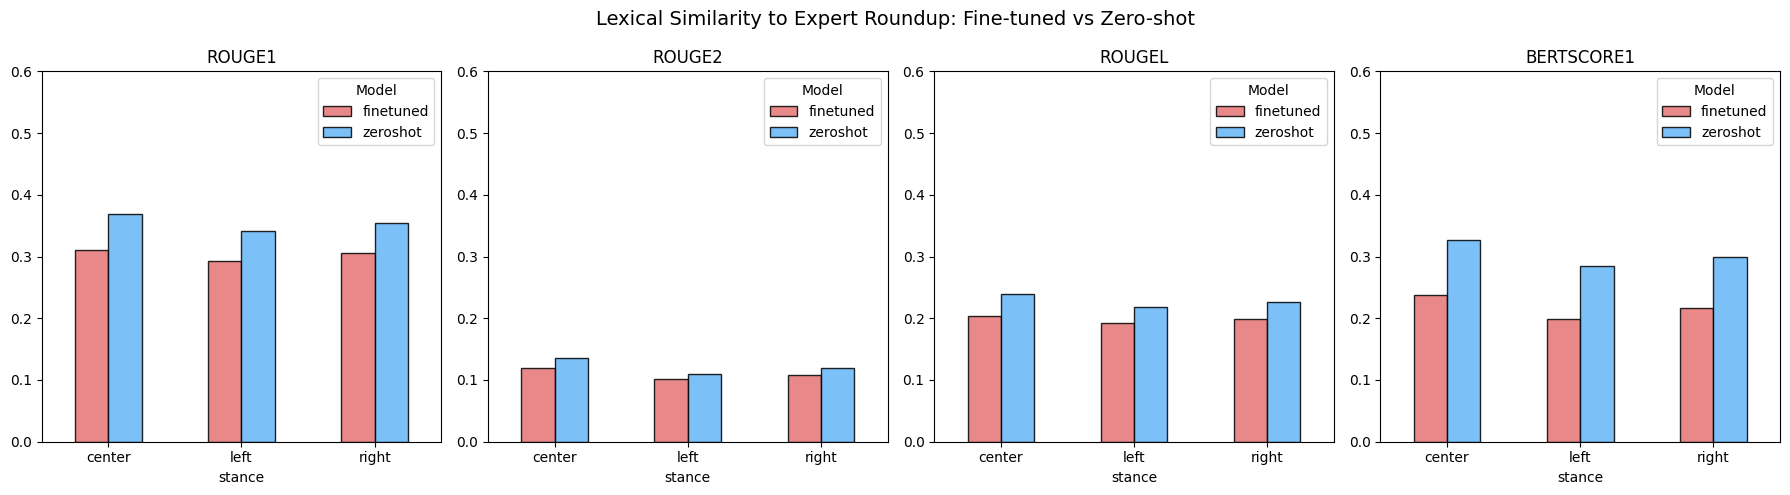

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Judge scores comparison bar chart
judge_summary = df.groupby(["model", "stance"])[["neutrality","faithfulness","roundup_alignment"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(["neutrality", "faithfulness", "roundup_alignment"]):
    pivot = judge_summary.pivot(index="stance", columns="model", values=col)
    pivot.plot(kind="bar", ax=axes[i], color=["#E57373","#64B5F6"], alpha=0.85, edgecolor="black")
    axes[i].set_title(f"{col.replace('_',' ').title()} by Stance", fontsize=12)
    axes[i].set_ylabel("Mean Score (0–5)")
    axes[i].set_ylim(0, 5.5)
    axes[i].axhline(y=df[col].astype(float).mean(), color='gray', linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title="Model")
plt.suptitle("LLM Judge Scores: Fine-tuned vs Zero-shot", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("judge_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. ROUGE comparison
rouge_summary = df.groupby(["model","stance"])[["rouge1_f","rouge2_f","rougeL_f","bertscore_f1"]].mean().reset_index()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(["rouge1_f","rouge2_f","rougeL_f","bertscore_f1"]):
    pivot = rouge_summary.pivot(index="stance", columns="model", values=col)
    pivot.plot(kind="bar", ax=axes[i], color=["#E57373","#64B5F6"], alpha=0.85, edgecolor="black")
    axes[i].set_title(col.replace("_f","").upper(), fontsize=12)
    axes[i].set_ylim(0, 0.6)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title="Model")
plt.suptitle("Lexical Similarity to Expert Roundup: Fine-tuned vs Zero-shot", fontsize=14)
plt.tight_layout()
plt.savefig("rouge_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

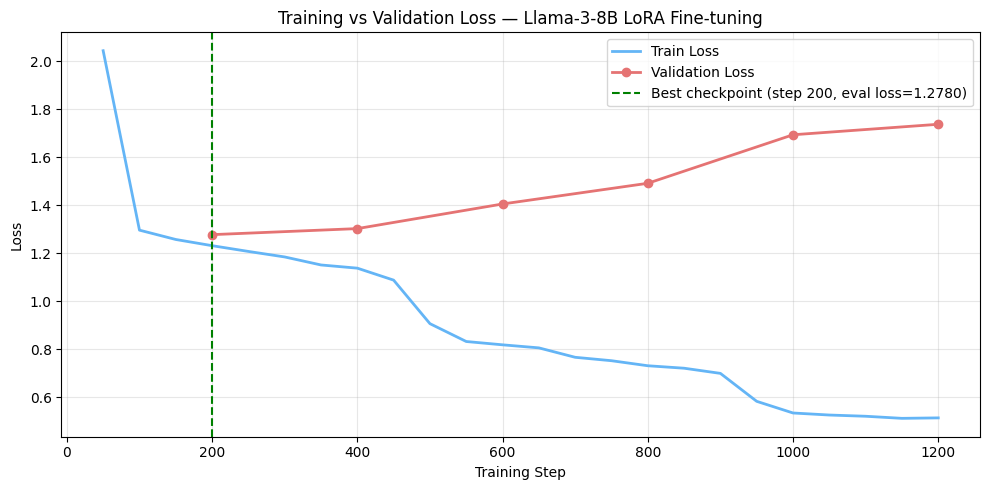

Best checkpoint: ./llama3-bias-lora-v5/checkpoint-200
Best eval loss: 1.2780 at step 200 (epoch 0.44)
Final eval loss: 1.7379 at step 1200
Overfitting gap: 0.4599


In [6]:
import json
import matplotlib.pyplot as plt

# Load trainer state from the full training run
with open("trainer_state.json") as f:  # rename your checkpoint-1200 version
    state = json.load(f)

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

for entry in state["log_history"]:
    if "loss" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_steps, train_loss, label="Train Loss", color="#64B5F6", linewidth=2)
ax.plot(eval_steps, eval_loss, label="Validation Loss", color="#E57373", linewidth=2, marker="o")
ax.axvline(x=200, color="green", linestyle="--", linewidth=1.5,
           label=f"Best checkpoint (step 200, eval loss={state['best_metric']:.4f})")
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss — Llama-3-8B LoRA Fine-tuning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Best checkpoint: {state['best_model_checkpoint']}")
print(f"Best eval loss: {state['best_metric']:.4f} at step 200 (epoch 0.44)")
print(f"Final eval loss: {eval_loss[-1]:.4f} at step {eval_steps[-1]}")
print(f"Overfitting gap: {eval_loss[-1] - state['best_metric']:.4f}")

In [7]:
# ── Qualitative Error Analysis Export ────────────────────────────────────────
df["faithfulness"]      = pd.to_numeric(df["faithfulness"], errors="coerce")
df["neutrality"]        = pd.to_numeric(df["neutrality"], errors="coerce")
df["roundup_alignment"] = pd.to_numeric(df["roundup_alignment"], errors="coerce")

EXPORT_COLS = ["example_id","topic","stance","model",
               "input_article","generated_summary","roundup_text",
               "neutrality","faithfulness","roundup_alignment","reasoning"]

# Case 1: FT low faithfulness — where did the model hallucinate?
low_faith_ft = df[
    (df["model"] == "finetuned") &
    (df["faithfulness"] <= 2)
][EXPORT_COLS].sort_values("faithfulness")

low_faith_ft.to_csv("error_analysis_low_faithfulness.csv", index=False)
print(f"Low faithfulness FT examples: {len(low_faith_ft)}")

# Case 2: FT high neutrality, low faithfulness — the trade-off in its purest form
tradeoff = df[
    (df["model"] == "finetuned") &
    (df["neutrality"] >= 4) &
    (df["faithfulness"] <= 2)
][EXPORT_COLS].sort_values("neutrality", ascending=False)

tradeoff.to_csv("error_analysis_tradeoff.csv", index=False)
print(f"High neutrality + low faithfulness FT examples: {len(tradeoff)}")

# Case 3: Side-by-side comparison — same story, same stance, both models
# Pick 15 stories where FT faithfulness is lowest
worst_stories = (
    df[df["model"] == "finetuned"]
    .groupby("example_id")["faithfulness"]
    .mean()
    .sort_values()
    .head(15)
    .index
)

comparison = df[df["example_id"].isin(worst_stories)].sort_values(
    ["example_id", "stance", "model"]
)[EXPORT_COLS]

comparison.to_csv("error_analysis_comparison.csv", index=False)
print(f"Side-by-side comparison rows: {len(comparison)} ({len(worst_stories)} stories × 3 stances × 2 models)")

# Case 4: ZS high faithfulness for contrast
high_faith_zs = df[
    (df["model"] == "zeroshot") &
    (df["faithfulness"] >= 4)
][EXPORT_COLS].sort_values("faithfulness", ascending=False).head(20)

high_faith_zs.to_csv("error_analysis_zeroshot_faithful.csv", index=False)
print(f"High faithfulness ZS examples (contrast set): {len(high_faith_zs)}")

print("\nExport complete. Manually review error_analysis_comparison.csv:")
print("For each FT example with low faithfulness, check:")
print("1. Is the 'hallucinated' fact actually present in roundup_text?")
print("2. Is it absent from input_article?")
print("If yes to both → model learned to generate roundup content, not summarize input.")

Low faithfulness FT examples: 477
High neutrality + low faithfulness FT examples: 253
Side-by-side comparison rows: 90 (15 stories × 3 stances × 2 models)
High faithfulness ZS examples (contrast set): 20

Export complete. Manually review error_analysis_comparison.csv:
For each FT example with low faithfulness, check:
1. Is the 'hallucinated' fact actually present in roundup_text?
2. Is it absent from input_article?
If yes to both → model learned to generate roundup content, not summarize input.


In [8]:
import os
os.makedirs("results", exist_ok=True)

# Aggregated numbers only — no article text, safe to publish
summary = df.groupby(["model", "stance"])[
    ["neutrality", "faithfulness", "roundup_alignment",
     "rouge1_f", "rouge2_f", "rougeL_f", "bertscore_f1",
     "valence", "arousal", "dominance"]
].mean().round(4)
summary.to_csv("results/results_summary.csv")

# Copy charts (they should already be saving to current dir — move them)
import shutil
for fname in ["training_curve.png", "judge_comparison.png", "rouge_comparison.png"]:
    if os.path.exists(fname):
        shutil.copy(fname, f"results/{fname}")
        
print("results/ folder ready for GitHub")
print(os.listdir("results"))

results/ folder ready for GitHub
['judge_comparison.png', 'results_summary.csv', 'rouge_comparison.png', 'training_curve.png']
